In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split,
                                      StratifiedKFold,
                                      cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                              classification_report,
                              confusion_matrix,
                              f1_score,
                              roc_auc_score)
import lightgbm as lgb
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8')

fault_map = {
    1: 'Normal',
    2: 'Refrigerant Leak',
    3: 'Refrigerant Overcharge',
    4: 'Reduced Condenser Flow',
    5: 'Reduced Evaporator Flow',
    6: 'Condenser Fouling',
    7: 'Excess Oil',
    8: 'Non-condensables'
}

feature_cols = [
    'TEI', 'TEO', 'TCI', 'TCO', 'kW',
    'TEA', 'TCA', 'TRE', 'TRC', 'TRC_sub',
    'T_suc', 'Tsh_suc', 'TR_dis', 'Tsh_dis',
    'TO_sump', 'PO_net'
]

print("✅ Libraries imported!")

✅ Libraries imported!


In [ ]:
base_path = '/content/drive/MyDrive/hvac_project/fdd_data/'

df_l1 = pd.read_parquet(base_path + 'fdd_level1.parquet')
df_l2 = pd.read_parquet(base_path + 'fdd_level2.parquet')

print(f"✅ Data loaded!")
print(f"   Level 1 : {df_l1.shape}")
print(f"   Level 2 : {df_l2.shape}")

✅ Data loaded!
   Level 1 : (11000, 19)
   Level 2 : (7000, 18)


In [ ]:
X_l1 = df_l1[feature_cols]
y_l1 = df_l1['binary_label']

print(f"✅ Level 1 — Features and target ready!")
print(f"   X shape : {X_l1.shape}")
print(f"   y shape : {y_l1.shape}")
print(f"\n   Class distribution:")
print(y_l1.value_counts().sort_index())

✅ Level 1 — Features and target ready!
   X shape : (11000, 16)
   y shape : (11000,)

   Class distribution:
binary_label
0    4000
1    7000
Name: count, dtype: int64


In [ ]:
X_l2 = df_l2[feature_cols]
y_l2 = df_l2['fault_label']

print(f"✅ Level 2 — Features and target ready!")
print(f"   X shape : {X_l2.shape}")
print(f"   y shape : {y_l2.shape}")
print(f"\n   Class distribution:")
for label, count in y_l2.value_counts().sort_index().items():
    print(f"   Label {label} ({fault_map[label]:25}): "
          f"{count:,}")

✅ Level 2 — Features and target ready!
   X shape : (7000, 16)
   y shape : (7000,)

   Class distribution:
   Label 2 (Refrigerant Leak         ): 1,000
   Label 3 (Refrigerant Overcharge   ): 1,000
   Label 4 (Reduced Condenser Flow   ): 1,000
   Label 5 (Reduced Evaporator Flow  ): 1,000
   Label 6 (Condenser Fouling        ): 1,000
   Label 7 (Excess Oil               ): 1,000
   Label 8 (Non-condensables         ): 1,000


In [ ]:
X_train_l1, X_test_l1, y_train_l1, y_test_l1 = \
    train_test_split(X_l1, y_l1,
                     test_size=0.2,
                     random_state=42,
                     stratify=y_l1)

print(f"✅ Level 1 split done!")
print(f"   Train : {X_train_l1.shape}")
print(f"   Test  : {X_test_l1.shape}")
print(f"\n   Train class dist:")
print(y_train_l1.value_counts().sort_index())
print(f"\n   Test class dist:")
print(y_test_l1.value_counts().sort_index())

✅ Level 1 split done!
   Train : (8800, 16)
   Test  : (2200, 16)

   Train class dist:
binary_label
0    3200
1    5600
Name: count, dtype: int64

   Test class dist:
binary_label
0     800
1    1400
Name: count, dtype: int64


In [ ]:
X_train_l2, X_test_l2, y_train_l2, y_test_l2 = \
    train_test_split(X_l2, y_l2,
                     test_size=0.2,
                     random_state=42,
                     stratify=y_l2)

print(f"✅ Level 2 split done!")
print(f"   Train : {X_train_l2.shape}")
print(f"   Test  : {X_test_l2.shape}")
print(f"\n   Train class dist:")
print(y_train_l2.value_counts().sort_index())

✅ Level 2 split done!
   Train : (5600, 16)
   Test  : (1400, 16)

   Train class dist:
fault_label
2    800
3    800
4    800
5    800
6    800
7    800
8    800
Name: count, dtype: int64


In [ ]:
scaler_l1 = StandardScaler()
scaler_l2 = StandardScaler()

X_train_l1_sc = scaler_l1.fit_transform(X_train_l1)
X_test_l1_sc  = scaler_l1.transform(X_test_l1)

X_train_l2_sc = scaler_l2.fit_transform(X_train_l2)
X_test_l2_sc  = scaler_l2.transform(X_test_l2)

print("✅ Features scaled with StandardScaler!")
print(f"   Train L1 range: "
      f"{X_train_l1_sc.min():.2f} to "
      f"{X_train_l1_sc.max():.2f}")
print(f"   Train L2 range: "
      f"{X_train_l2_sc.min():.2f} to "
      f"{X_train_l2_sc.max():.2f}")

# Save scalers
joblib.dump(scaler_l1,
    '/content/drive/MyDrive/hvac_project/'
    'fdd_scaler_l1.pkl')
joblib.dump(scaler_l2,
    '/content/drive/MyDrive/hvac_project/'
    'fdd_scaler_l2.pkl')
print("✅ Scalers saved!")

✅ Features scaled with StandardScaler!
   Train L1 range: -3.86 to 5.81
   Train L2 range: -4.25 to 4.90
✅ Scalers saved!


In [ ]:
def evaluate_classifier(y_test, y_pred, y_pred_proba,
                         model_name, level, class_names):
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{'='*50}")
    print(f"{model_name} — Level {level} Results")
    print(f"{'='*50}")
    print(f"Accuracy         : {acc:.4f} ({acc*100:.2f}%)")
    print(f"F1 Score (weighted): {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=class_names))

    return (acc, f1)


def plot_confusion_matrix(y_test, y_pred,
                           class_names, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(max(6, len(class_names)*1.2),
                        max(5, len(class_names))))
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

print("✅ Evaluation functions defined!")

✅ Evaluation functions defined!


Training Random Forest — Level 1 (Binary)...
✅ Random Forest Level 1 trained!

Random Forest — Level 1 Results
Accuracy         : 0.9900 (99.00%)
F1 Score (weighted): 0.9900

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       800
      Faulty       0.99      1.00      0.99      1400

    accuracy                           0.99      2200
   macro avg       0.99      0.99      0.99      2200
weighted avg       0.99      0.99      0.99      2200



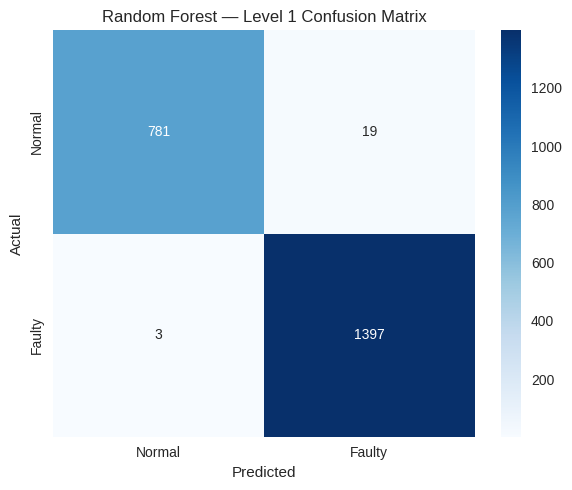

✅ RF Level 1 saved!


In [ ]:
print("Training Random Forest — Level 1 (Binary)...")

rf_l1 = RandomForestClassifier(
    n_estimators    = 200,
    max_depth       = None,
    min_samples_leaf= 2,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)

rf_l1.fit(X_train_l1_sc, y_train_l1)
print("✅ Random Forest Level 1 trained!")

y_pred_rf_l1       = rf_l1.predict(X_test_l1_sc)
y_pred_proba_rf_l1 = rf_l1.predict_proba(X_test_l1_sc)

class_names_l1 = ['Normal', 'Faulty']
rf_l1_scores = evaluate_classifier(
    y_test_l1, y_pred_rf_l1,
    y_pred_proba_rf_l1,
    'Random Forest', 1, class_names_l1
)

plot_confusion_matrix(
    y_test_l1, y_pred_rf_l1,
    class_names_l1,
    'Random Forest — Level 1 Confusion Matrix'
)

joblib.dump(rf_l1,
    '/content/drive/MyDrive/hvac_project/'
    'fdd_rf_l1.pkl')
print("✅ RF Level 1 saved!")

Training Random Forest — Level 2 (Multi-class)...
✅ Random Forest Level 2 trained!

Random Forest — Level 2 Results
Accuracy         : 0.9971 (99.71%)
F1 Score (weighted): 0.9971

Classification Report:
                         precision    recall  f1-score   support

       Refrigerant Leak       1.00      1.00      1.00       200
 Refrigerant Overcharge       1.00      0.99      0.99       200
 Reduced Condenser Flow       1.00      0.99      1.00       200
Reduced Evaporator Flow       0.99      1.00      1.00       200
      Condenser Fouling       1.00      1.00      1.00       200
             Excess Oil       0.99      0.99      0.99       200
       Non-condensables       1.00      1.00      1.00       200

               accuracy                           1.00      1400
              macro avg       1.00      1.00      1.00      1400
           weighted avg       1.00      1.00      1.00      1400



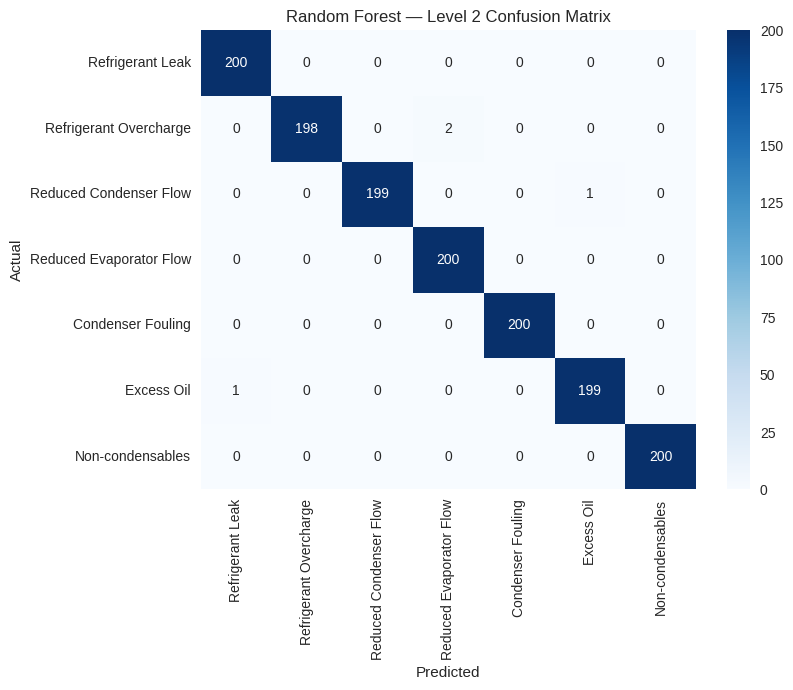

✅ RF Level 2 saved!


In [ ]:
print("Training Random Forest — Level 2 (Multi-class)...")

rf_l2 = RandomForestClassifier(
    n_estimators    = 200,
    max_depth       = None,
    min_samples_leaf= 2,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)

rf_l2.fit(X_train_l2_sc, y_train_l2)
print("✅ Random Forest Level 2 trained!")

y_pred_rf_l2       = rf_l2.predict(X_test_l2_sc)
y_pred_proba_rf_l2 = rf_l2.predict_proba(X_test_l2_sc)

class_names_l2 = [fault_map[l]
                  for l in sorted(y_l2.unique())]
rf_l2_scores = evaluate_classifier(
    y_test_l2, y_pred_rf_l2,
    y_pred_proba_rf_l2,
    'Random Forest', 2, class_names_l2
)

plot_confusion_matrix(
    y_test_l2, y_pred_rf_l2,
    class_names_l2,
    'Random Forest — Level 2 Confusion Matrix'
)

joblib.dump(rf_l2,
    '/content/drive/MyDrive/hvac_project/'
    'fdd_rf_l2.pkl')
print("✅ RF Level 2 saved!")

Training LightGBM — Level 1 (Binary)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0550397
[200]	valid_0's binary_logloss: 0.0208727
[300]	valid_0's binary_logloss: 0.011666
[400]	valid_0's binary_logloss: 0.00895148
[500]	valid_0's binary_logloss: 0.00693734
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.00693734
✅ LightGBM Level 1 trained!

LightGBM — Level 1 Results
Accuracy         : 0.9968 (99.68%)
F1 Score (weighted): 0.9968

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       800
      Faulty       1.00      1.00      1.00      1400

    accuracy                           1.00      2200
   macro avg       1.00      1.00      1.00      2200
weighted avg       1.00      1.00      1.00      2200



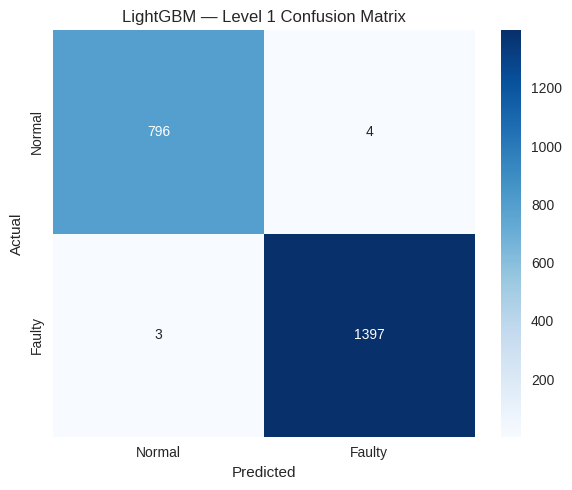

✅ LightGBM Level 1 saved!


In [ ]:
print("Training LightGBM — Level 1 (Binary)...")

lgb_l1 = lgb.LGBMClassifier(
    n_estimators    = 500,
    learning_rate   = 0.05,
    num_leaves      = 31,
    max_depth       = -1,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
)

lgb_l1.fit(X_train_l1_sc, y_train_l1,
           eval_set=[(X_test_l1_sc, y_test_l1)],
           callbacks=[lgb.early_stopping(50),
                      lgb.log_evaluation(100)])
print("✅ LightGBM Level 1 trained!")

y_pred_lgb_l1       = lgb_l1.predict(X_test_l1_sc)
y_pred_proba_lgb_l1 = lgb_l1.predict_proba(X_test_l1_sc)

lgb_l1_scores = evaluate_classifier(
    y_test_l1, y_pred_lgb_l1,
    y_pred_proba_lgb_l1,
    'LightGBM', 1, class_names_l1
)

plot_confusion_matrix(
    y_test_l1, y_pred_lgb_l1,
    class_names_l1,
    'LightGBM — Level 1 Confusion Matrix'
)

joblib.dump(lgb_l1,
    '/content/drive/MyDrive/hvac_project/'
    'fdd_lgb_l1.pkl')
print("✅ LightGBM Level 1 saved!")

Training LightGBM — Level 2 (Multi-class)...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.011785
[200]	valid_0's multi_logloss: 0.00627947
[300]	valid_0's multi_logloss: 0.00551985
[400]	valid_0's multi_logloss: 0.00516583
[500]	valid_0's multi_logloss: 0.00507473
Did not meet early stopping. Best iteration is:
[494]	valid_0's multi_logloss: 0.00505874
✅ LightGBM Level 2 trained!

LightGBM — Level 2 Results
Accuracy         : 0.9964 (99.64%)
F1 Score (weighted): 0.9964

Classification Report:
                         precision    recall  f1-score   support

       Refrigerant Leak       0.99      1.00      1.00       200
 Refrigerant Overcharge       1.00      0.98      0.99       200
 Reduced Condenser Flow       1.00      1.00      1.00       200
Reduced Evaporator Flow       0.99      1.00      1.00       200
      Condenser Fouling       1.00      0.99      1.00       200
             Excess Oil       0.99      0.99      0.99       2

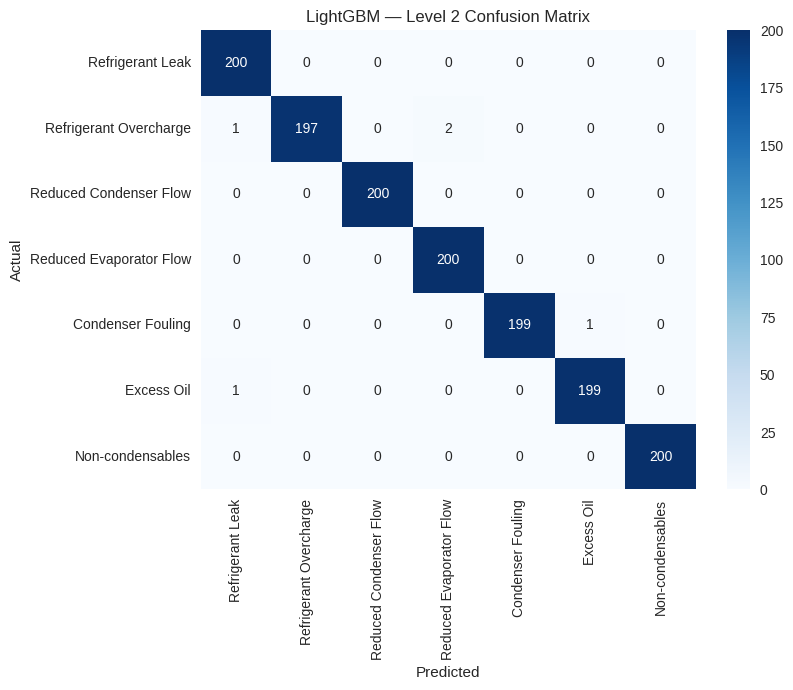

✅ LightGBM Level 2 saved!


In [ ]:
print("Training LightGBM — Level 2 (Multi-class)...")

lgb_l2 = lgb.LGBMClassifier(
    n_estimators    = 500,
    learning_rate   = 0.05,
    num_leaves      = 31,
    objective       = 'multiclass',
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
)

lgb_l2.fit(X_train_l2_sc, y_train_l2,
           eval_set=[(X_test_l2_sc, y_test_l2)],
           callbacks=[lgb.early_stopping(50),
                      lgb.log_evaluation(100)])
print("✅ LightGBM Level 2 trained!")

y_pred_lgb_l2       = lgb_l2.predict(X_test_l2_sc)
y_pred_proba_lgb_l2 = lgb_l2.predict_proba(X_test_l2_sc)

lgb_l2_scores = evaluate_classifier(
    y_test_l2, y_pred_lgb_l2,
    y_pred_proba_lgb_l2,
    'LightGBM', 2, class_names_l2
)

plot_confusion_matrix(
    y_test_l2, y_pred_lgb_l2,
    class_names_l2,
    'LightGBM — Level 2 Confusion Matrix'
)

joblib.dump(lgb_l2,
    '/content/drive/MyDrive/hvac_project/'
    'fdd_lgb_l2.pkl')
print("✅ LightGBM Level 2 saved!")

Training XGBoost — Level 1 (Binary)...
[0]	validation_0-logloss:0.66287
[100]	validation_0-logloss:0.11301
[200]	validation_0-logloss:0.05047
[300]	validation_0-logloss:0.02963
[400]	validation_0-logloss:0.02290
[499]	validation_0-logloss:0.01881
✅ XGBoost Level 1 trained!

XGBoost — Level 1 Results
Accuracy         : 0.9955 (99.55%)
F1 Score (weighted): 0.9955

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       800
      Faulty       1.00      1.00      1.00      1400

    accuracy                           1.00      2200
   macro avg       1.00      0.99      1.00      2200
weighted avg       1.00      1.00      1.00      2200



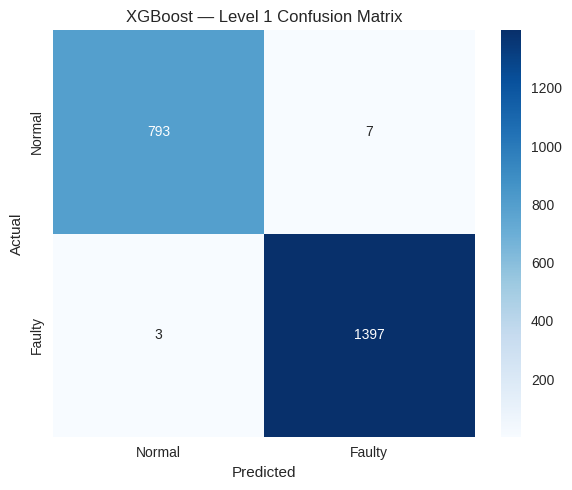

✅ XGBoost Level 1 saved!


In [ ]:
print("Training XGBoost — Level 1 (Binary)...")

# Calculate scale_pos_weight for imbalance
normal_count = (y_train_l1 == 0).sum()
faulty_count = (y_train_l1 == 1).sum()
scale_weight = normal_count / faulty_count

xgb_l1 = xgb.XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    scale_pos_weight  = scale_weight,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
    eval_metric       = 'logloss',
    early_stopping_rounds = 50
)

xgb_l1.fit(X_train_l1_sc, y_train_l1,
           eval_set=[(X_test_l1_sc, y_test_l1)],
           verbose=100)
print("✅ XGBoost Level 1 trained!")

y_pred_xgb_l1       = xgb_l1.predict(X_test_l1_sc)
y_pred_proba_xgb_l1 = xgb_l1.predict_proba(X_test_l1_sc)

xgb_l1_scores = evaluate_classifier(
    y_test_l1, y_pred_xgb_l1,
    y_pred_proba_xgb_l1,
    'XGBoost', 1, class_names_l1
)

plot_confusion_matrix(
    y_test_l1, y_pred_xgb_l1,
    class_names_l1,
    'XGBoost — Level 1 Confusion Matrix'
)

xgb_l1.save_model(
    '/content/drive/MyDrive/hvac_project/'
    'fdd_xgb_l1.json')
print("✅ XGBoost Level 1 saved!")

Training XGBoost — Level 2 (Multi-class)...
Original labels  : [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Encoded labels   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
[0]	validation_0-mlogloss:1.79690
[100]	validation_0-mlogloss:0.04093
[200]	validation_0-mlogloss:0.01495
[300]	validation_0-mlogloss:0.01166
[400]	validation_0-mlogloss:0.01022
[499]	validation_0-mlogloss:0.00949
✅ XGBoost Level 2 trained!

XGBoost — Level 2 Results
Accuracy         : 0.9971 (99.71%)
F1 Score (weighted): 0.9971

Classification Report:
                         precision    recall  f1-score   support

       Refrigerant Leak       1.00      1.00      1.00       200
 Refrigerant Overcharge       0.99      0.99      0.99       200
 Reduced Condenser Flow       1.00      1.00      1.00       200
Reduced Evaporator Flow       0.99      0.99      0.99       200
      Condenser Fouling       1.00      1.00      1.0

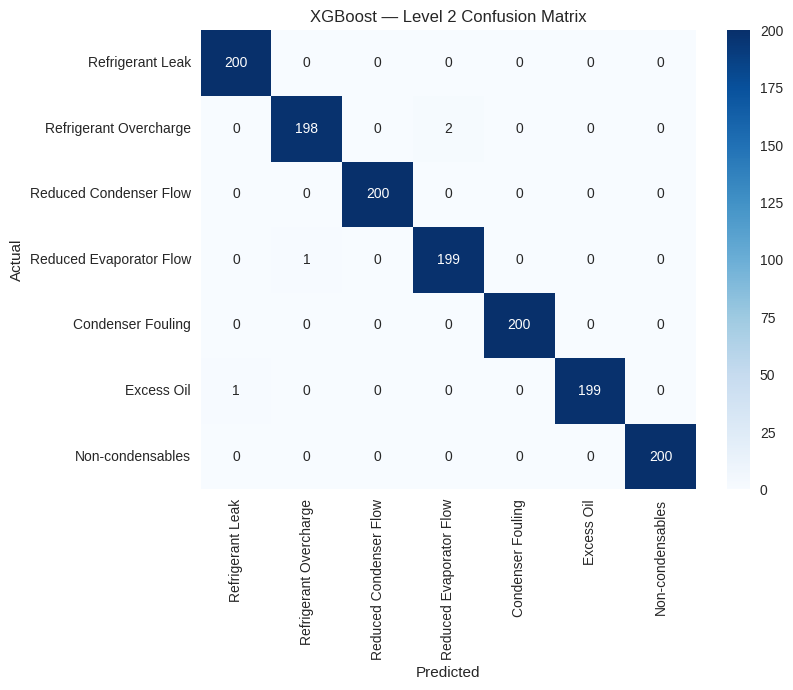

✅ XGBoost Level 2 and encoder saved!


In [ ]:
print("Training XGBoost — Level 2 (Multi-class)...")

# XGBoost requires classes starting from 0
# Current labels are 2-8, need to encode to 0-6
from sklearn.preprocessing import LabelEncoder

le_xgb = LabelEncoder()
y_train_l2_encoded = le_xgb.fit_transform(y_train_l2)
y_test_l2_encoded  = le_xgb.transform(y_test_l2)

print(f"Original labels  : {sorted(y_train_l2.unique())}")
print(f"Encoded labels   : {sorted(np.unique(y_train_l2_encoded))}")

xgb_l2 = xgb.XGBClassifier(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    objective             = 'multi:softmax',
    num_class             = len(np.unique(y_train_l2_encoded)),
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 50
)

xgb_l2.fit(X_train_l2_sc, y_train_l2_encoded,
           eval_set=[(X_test_l2_sc, y_test_l2_encoded)],
           verbose=100)
print("✅ XGBoost Level 2 trained!")

# Predict and decode back to original labels
y_pred_xgb_l2_encoded = xgb_l2.predict(X_test_l2_sc)
y_pred_xgb_l2         = le_xgb.inverse_transform(
    y_pred_xgb_l2_encoded)
y_pred_proba_xgb_l2   = xgb_l2.predict_proba(X_test_l2_sc)

xgb_l2_scores = evaluate_classifier(
    y_test_l2, y_pred_xgb_l2,
    y_pred_proba_xgb_l2,
    'XGBoost', 2, class_names_l2
)

plot_confusion_matrix(
    y_test_l2, y_pred_xgb_l2,
    class_names_l2,
    'XGBoost — Level 2 Confusion Matrix'
)

xgb_l2.save_model(
    '/content/drive/MyDrive/hvac_project/'
    'fdd_xgb_l2.json')
joblib.dump(le_xgb,
    '/content/drive/MyDrive/hvac_project/'
    'fdd_xgb_l2_encoder.pkl')
print("✅ XGBoost Level 2 and encoder saved!")

FEATURE IMPORTANCE ANALYSIS


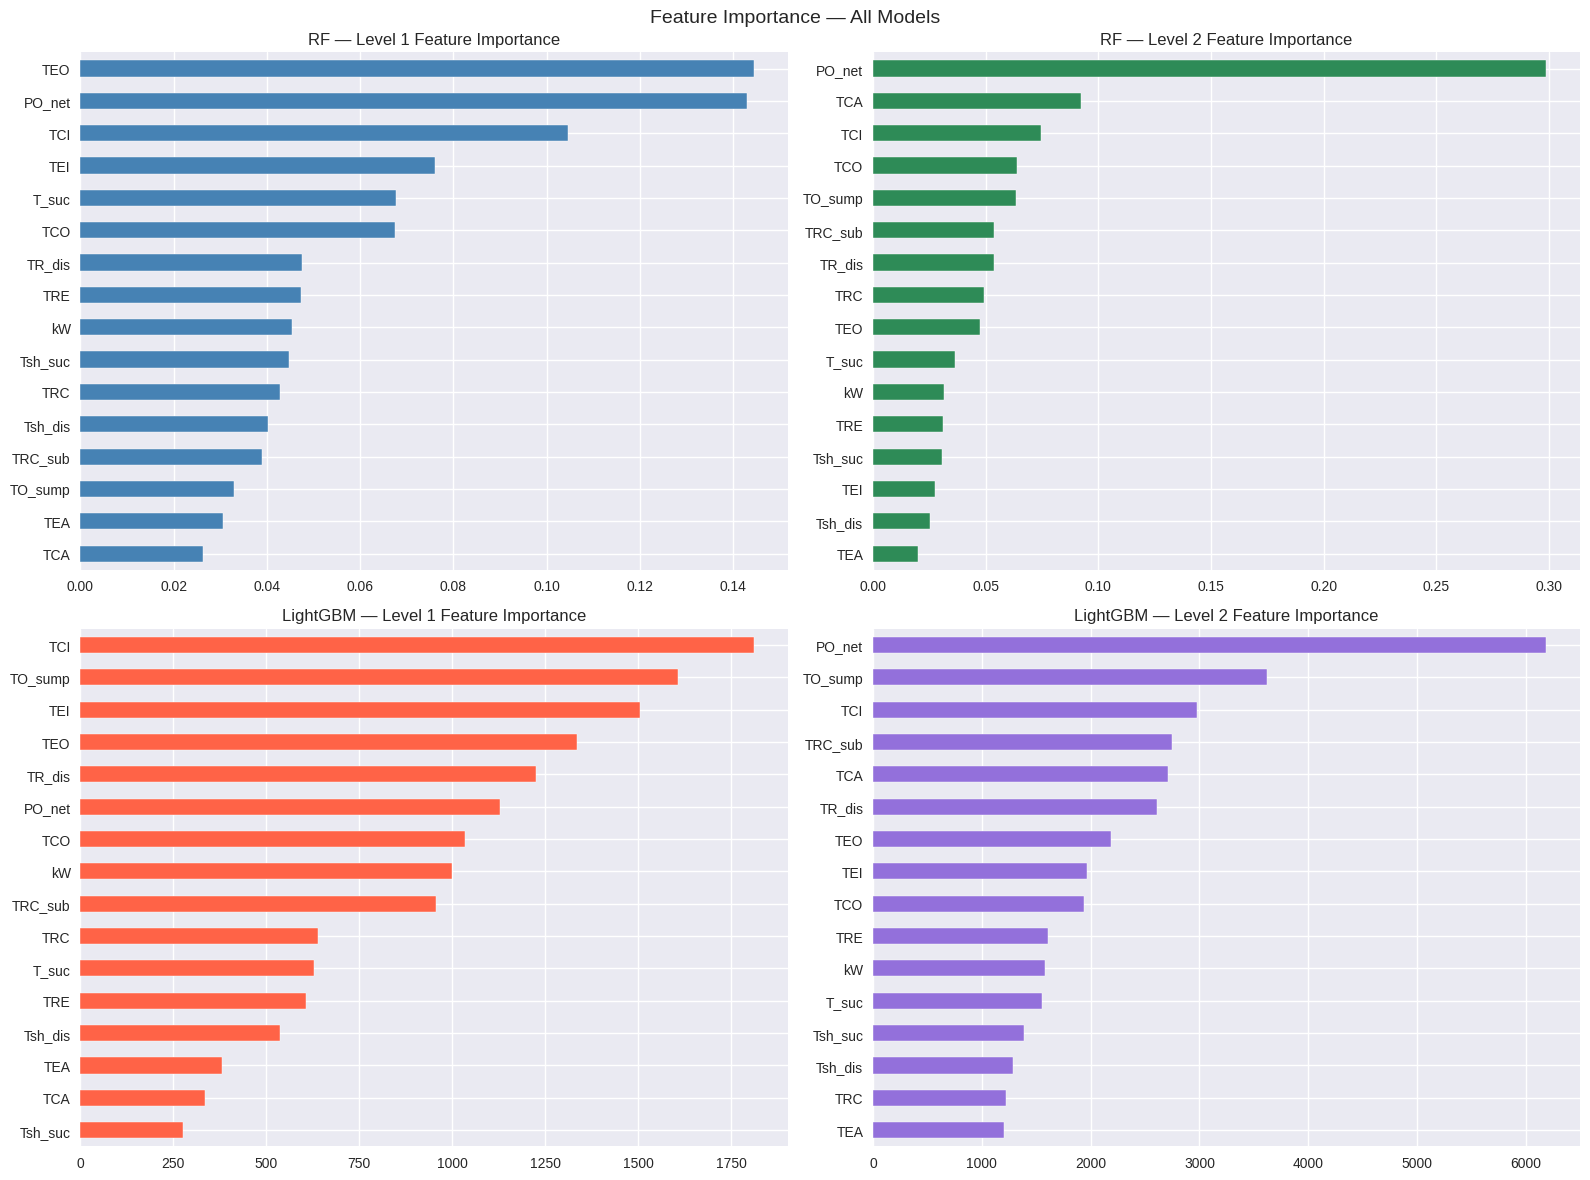

In [ ]:
print("=" * 50)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RF Level 1
rf_imp_l1 = pd.Series(
    rf_l1.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)
rf_imp_l1.plot(kind='barh', ax=axes[0,0],
               color='steelblue', edgecolor='white')
axes[0,0].set_title('RF — Level 1 Feature Importance')

# RF Level 2
rf_imp_l2 = pd.Series(
    rf_l2.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)
rf_imp_l2.plot(kind='barh', ax=axes[0,1],
               color='seagreen', edgecolor='white')
axes[0,1].set_title('RF — Level 2 Feature Importance')

# LGB Level 1
lgb_imp_l1 = pd.Series(
    lgb_l1.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)
lgb_imp_l1.plot(kind='barh', ax=axes[1,0],
                color='tomato', edgecolor='white')
axes[1,0].set_title('LightGBM — Level 1 Feature Importance')

# LGB Level 2
lgb_imp_l2 = pd.Series(
    lgb_l2.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)
lgb_imp_l2.plot(kind='barh', ax=axes[1,1],
                color='mediumpurple', edgecolor='white')
axes[1,1].set_title('LightGBM — Level 2 Feature Importance')

plt.suptitle('Feature Importance — All Models',
             fontsize=14)
plt.tight_layout()
plt.show()

FINAL ML COMPARISON — HIERARCHICAL FDD
        Model  L1 Acc  L1 F1  L2 Acc  L2 F1
Random Forest  0.9900 0.9900  0.9971 0.9971
     LightGBM  0.9968 0.9968  0.9964 0.9964
      XGBoost  0.9955 0.9955  0.9971 0.9971


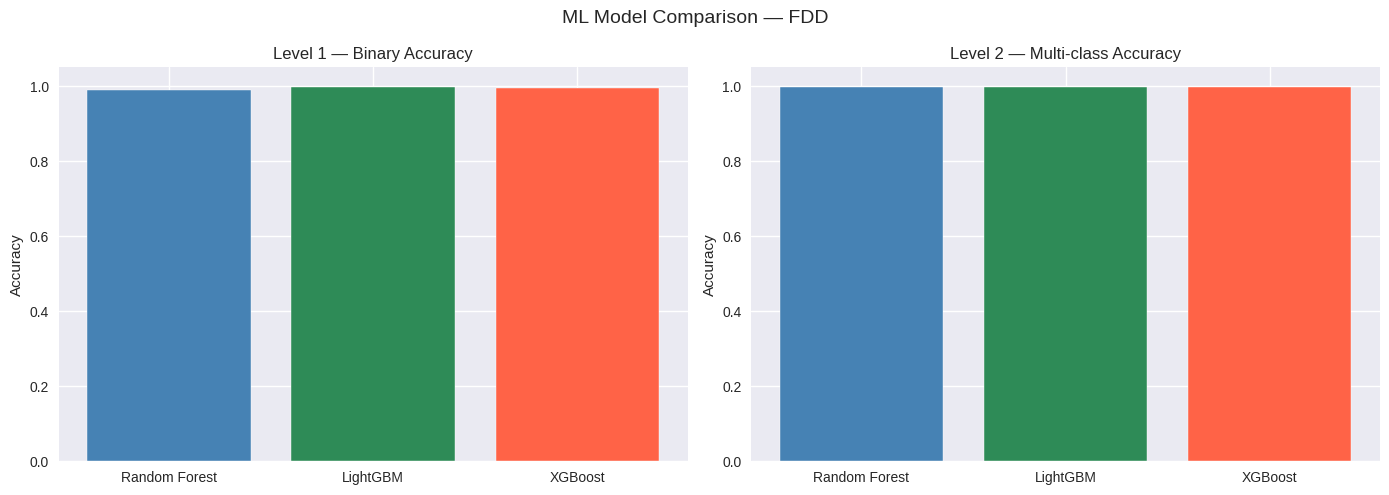

In [ ]:
print("=" * 60)
print("FINAL ML COMPARISON — HIERARCHICAL FDD")
print("=" * 60)

summary = pd.DataFrame({
    'Model'    : ['Random Forest', 'LightGBM', 'XGBoost'],
    'L1 Acc'   : [rf_l1_scores[0],
                  lgb_l1_scores[0],
                  xgb_l1_scores[0]],
    'L1 F1'    : [rf_l1_scores[1],
                  lgb_l1_scores[1],
                  xgb_l1_scores[1]],
    'L2 Acc'   : [rf_l2_scores[0],
                  lgb_l2_scores[0],
                  xgb_l2_scores[0]],
    'L2 F1'    : [rf_l2_scores[1],
                  lgb_l2_scores[1],
                  xgb_l2_scores[1]],
})

print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'seagreen', 'tomato']

axes[0].bar(summary['Model'], summary['L1 Acc'],
            color=colors, edgecolor='white')
axes[0].set_title('Level 1 — Binary Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)

axes[1].bar(summary['Model'], summary['L2 Acc'],
            color=colors, edgecolor='white')
axes[1].set_title('Level 2 — Multi-class Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)

plt.suptitle('ML Model Comparison — FDD', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("--- Overfitting Check ---")
print("Comparing Train vs Test Accuracy\n")

models_check = [
    ('Random Forest L1', rf_l1,
     X_train_l1_sc, y_train_l1,
     X_test_l1_sc,  y_test_l1),
    ('Random Forest L2', rf_l2,
     X_train_l2_sc, y_train_l2,
     X_test_l2_sc,  y_test_l2),
    ('LightGBM L1', lgb_l1,
     X_train_l1_sc, y_train_l1,
     X_test_l1_sc,  y_test_l1),
    ('LightGBM L2', lgb_l2,
     X_train_l2_sc, y_train_l2,
     X_test_l2_sc,  y_test_l2),
]

for name, model, X_tr, y_tr, X_te, y_te in models_check:
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_acc  = accuracy_score(y_te, model.predict(X_te))
    gap       = train_acc - test_acc
    status    = '✅ No overfit' if gap < 0.01 else '⚠️ Possible overfit'
    print(f"{name:20} → Train: {train_acc:.4f} | "
          f"Test: {test_acc:.4f} | "
          f"Gap: {gap:.4f} {status}")

--- Overfitting Check ---
Comparing Train vs Test Accuracy

Random Forest L1     → Train: 0.9999 | Test: 0.9900 | Gap: 0.0099 ✅ No overfit
Random Forest L2     → Train: 0.9998 | Test: 0.9971 | Gap: 0.0027 ✅ No overfit
LightGBM L1          → Train: 1.0000 | Test: 0.9968 | Gap: 0.0032 ✅ No overfit
LightGBM L2          → Train: 1.0000 | Test: 0.9964 | Gap: 0.0036 ✅ No overfit
